# 04 — Model Evaluation

**Inputs:**
- `packages/ml/pricing_model.pkl` — trained XGBoost bundle
- `datasets/ebay_test_set.parquet` — held-out test set from notebook 03

## What we measure

All metrics are computed in **USD space** (after `expm1` inverse-transform) so the numbers are interpretable as dollar errors:

| Metric | What it tells us |
|--------|------------------|
| RMSE | Penalises large errors heavily — sensitive to outliers |
| MAE | Average absolute dollar error — easy to communicate |
| MAPE | % error relative to actual price — scale-independent |
| R² | Fraction of price variance explained by the model |

In [1]:
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

MODEL_PATH    = Path('../packages/ml/pricing_model.pkl')
TEST_SET_PATH = Path('../datasets/ebay_test_set.parquet')

---
## 1. Load Model & Test Set

In [2]:
with open(MODEL_PATH, 'rb') as f:
    bundle = pickle.load(f)

model         = bundle['model']
feature_names = bundle['feature_names']

test_df = pd.read_parquet(TEST_SET_PATH)

X_test       = test_df[feature_names].values
y_true_log   = test_df['log_price_true'].values
y_true_usd   = test_df['price_usd_true'].values

print(f'Model loaded: {model.best_iteration} boosting rounds')
print(f'Test rows: {len(X_test):,}')

Model loaded: 280 boosting rounds
Test rows: 2,536


---
## 2. Generate Predictions

In [3]:
# predict in log space, then inverse-transform to USD
y_pred_log = model.predict(X_test)
y_pred_usd = np.expm1(y_pred_log)

# clip negative predictions (shouldn't happen but guards against edge cases)
y_pred_usd = np.maximum(y_pred_usd, 0.01)

print(f'Predicted price range: ${y_pred_usd.min():.2f} – ${y_pred_usd.max():.2f}')
print(f'Actual price range:    ${y_true_usd.min():.2f} – ${y_true_usd.max():.2f}')

Predicted price range: $6.05 – $824.43
Actual price range:    $1.75 – $1200.00


---
## 3. Regression Metrics

In [4]:
rmse = mean_squared_error(y_true_usd, y_pred_usd) ** 0.5
mae  = mean_absolute_error(y_true_usd, y_pred_usd)
r2   = r2_score(y_true_usd, y_pred_usd)

# MAPE: mean absolute percentage error — excludes near-zero actuals
mask = y_true_usd > 1.0
mape = (np.abs(y_true_usd[mask] - y_pred_usd[mask]) / y_true_usd[mask]).mean() * 100

# median absolute error — more robust to outlier listings
medae = np.median(np.abs(y_true_usd - y_pred_usd))

print('=== Test Set Metrics (USD) ===')
print(f'RMSE:   ${rmse:.2f}')
print(f'MAE:    ${mae:.2f}')
print(f'MedAE:  ${medae:.2f}')
print(f'MAPE:    {mape:.1f}%')
print(f'R²:      {r2:.4f}')

# log-space metrics (what XGBoost optimised)
rmse_log = mean_squared_error(y_true_log, y_pred_log) ** 0.5
print(f'\nRMSE (log space): {rmse_log:.4f}')

=== Test Set Metrics (USD) ===
RMSE:   $156.46
MAE:    $80.10
MedAE:  $32.67
MAPE:    131.5%
R²:      0.2586

RMSE (log space): 1.0212


---
## 4. Actual vs Predicted

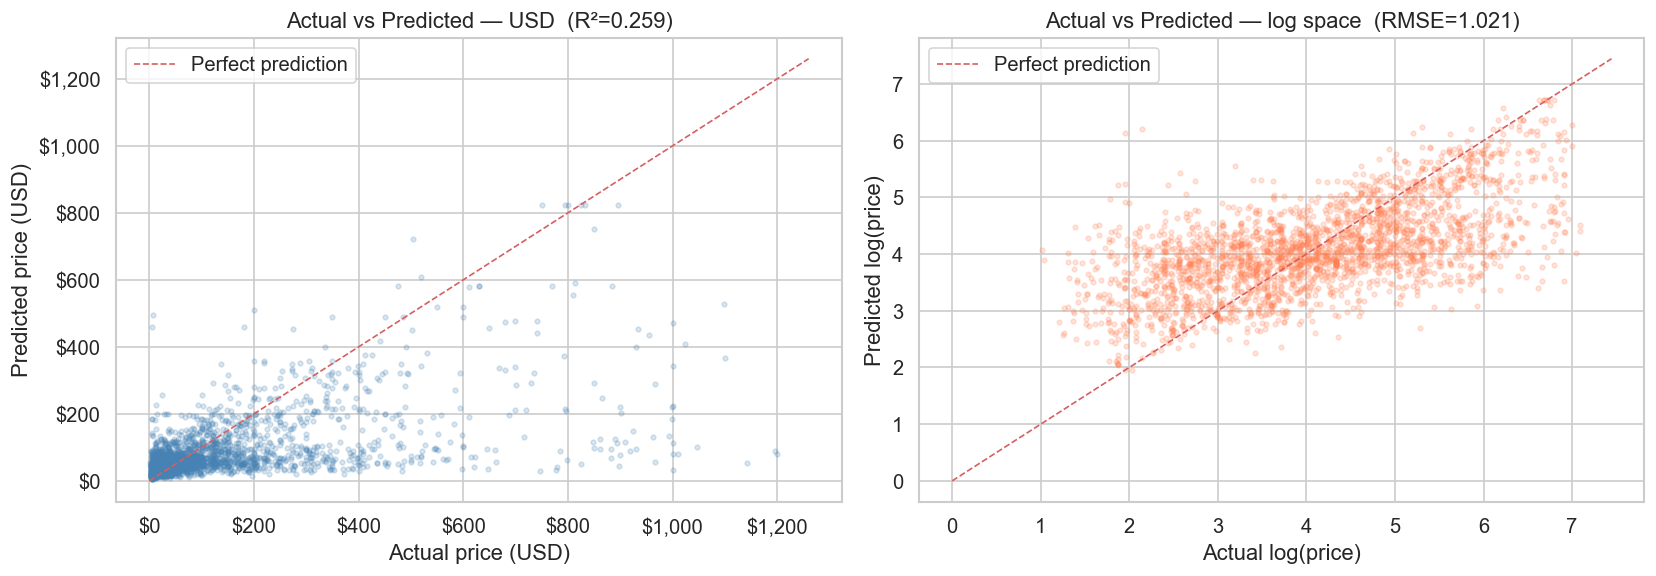

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# USD space
lim = max(y_true_usd.max(), y_pred_usd.max()) * 1.05
axes[0].scatter(y_true_usd, y_pred_usd, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual price (USD)')
axes[0].set_ylabel('Predicted price (USD)')
axes[0].set_title(f'Actual vs Predicted — USD  (R²={r2:.3f})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# log space — cleaner view without outlier distortion
lim_log = max(y_true_log.max(), y_pred_log.max()) * 1.05
axes[1].scatter(y_true_log, y_pred_log, alpha=0.2, s=8, color='coral')
axes[1].plot([0, lim_log], [0, lim_log], 'r--', linewidth=1, label='Perfect prediction')
axes[1].set_xlabel('Actual log(price)')
axes[1].set_ylabel('Predicted log(price)')
axes[1].set_title(f'Actual vs Predicted — log space  (RMSE={rmse_log:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Residual Analysis

Residuals should be centred at zero with no strong pattern against predicted value.  
A systematic pattern would indicate the model is under/over-predicting at certain price ranges.

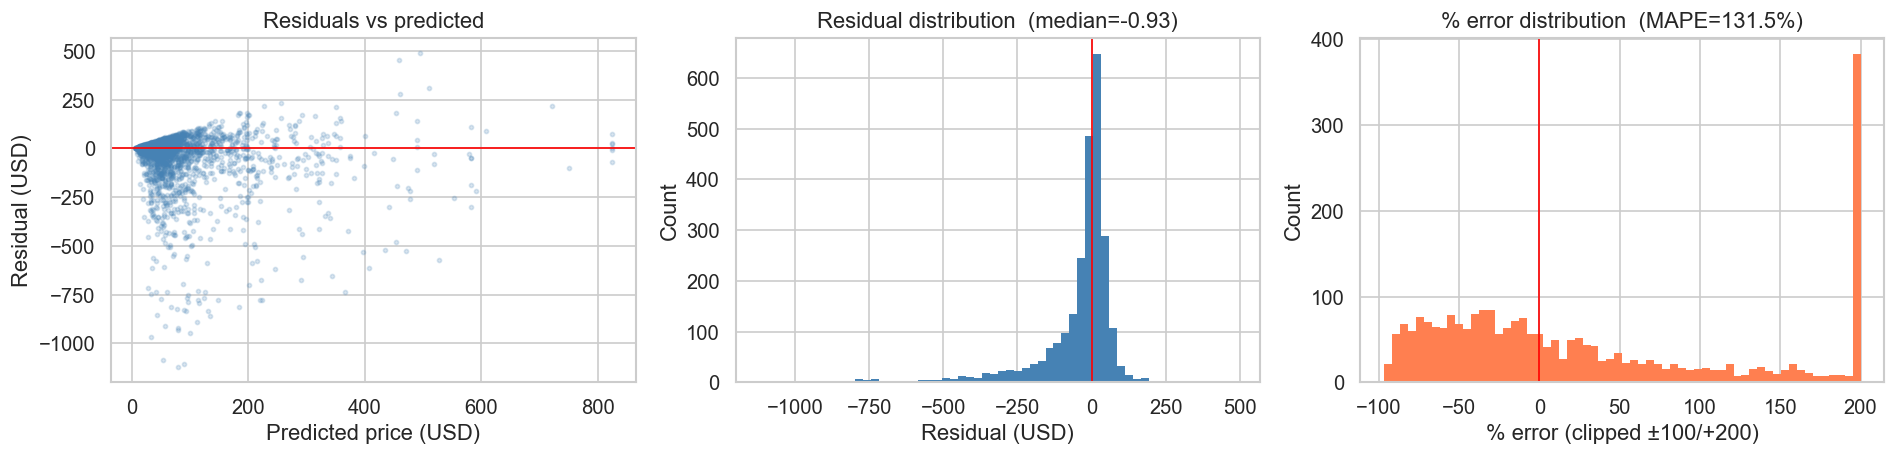

In [6]:
residuals_usd = y_pred_usd - y_true_usd
residuals_pct = (y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# residuals vs predicted (USD) — check for heteroscedasticity
axes[0].scatter(y_pred_usd, residuals_usd, alpha=0.2, s=6, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted price (USD)')
axes[0].set_ylabel('Residual (USD)')
axes[0].set_title('Residuals vs predicted')

# residual distribution
axes[1].hist(residuals_usd, bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linewidth=1)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual distribution  (median={np.median(residuals_usd):.2f})')

# percentage error distribution
axes[2].hist(np.clip(residuals_pct, -100, 200), bins=60, color='coral', edgecolor='none')
axes[2].axvline(0, color='red', linewidth=1)
axes[2].set_xlabel('% error (clipped ±100/+200)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'% error distribution  (MAPE={mape:.1f}%)')

plt.tight_layout()
plt.show()

---
## 6. Feature Importance

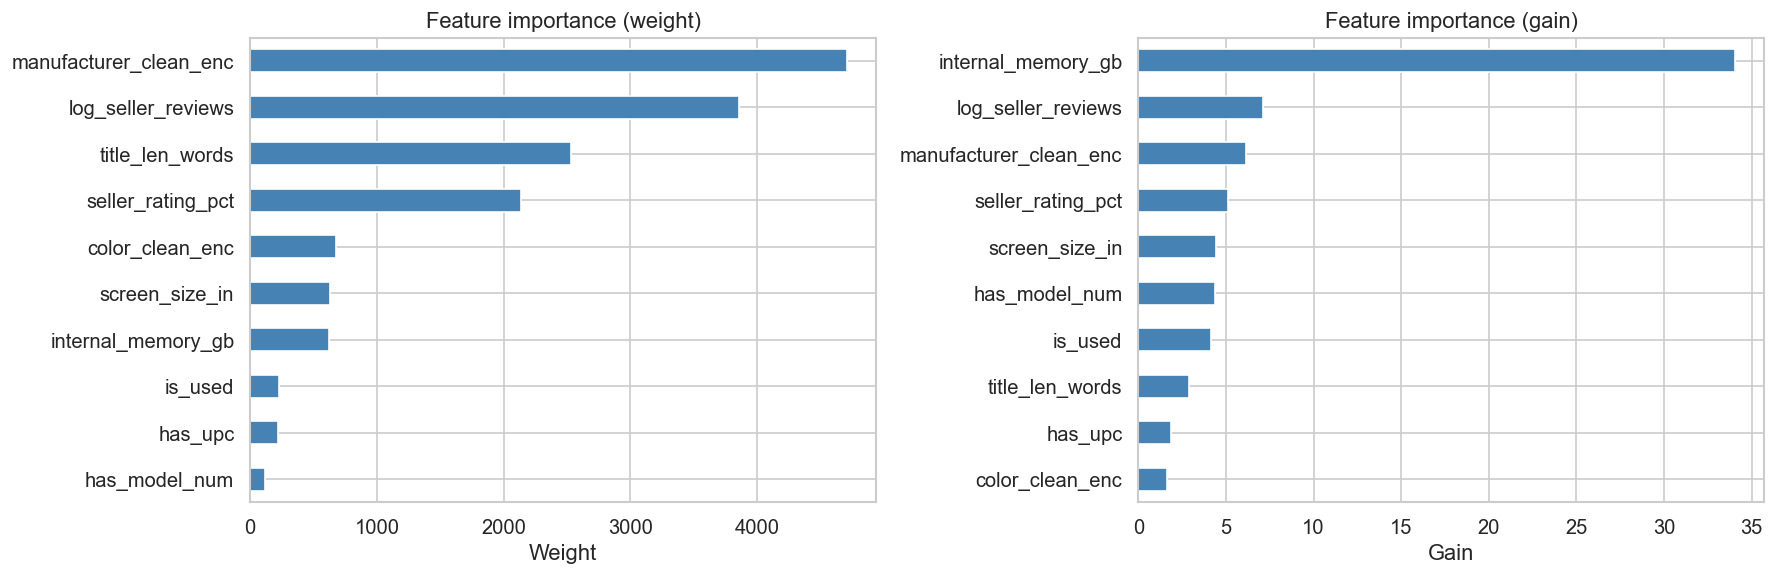

In [7]:
import xgboost as xgb

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, importance_type in zip(axes, ['weight', 'gain']):
    scores = model.get_booster().get_score(importance_type=importance_type)
    # map back from f0/f1/... to readable names
    named = {
        feature_names[int(k[1:])]: v
        for k, v in scores.items()
    }
    imp_df = pd.Series(named).sort_values()
    imp_df.plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'Feature importance ({importance_type})')
    ax.set_xlabel(importance_type.capitalize())

plt.tight_layout()
plt.show()

---
## 7. Error Breakdown by Condition (`is_used`)

The pricing agent relies heavily on `is_used` to distinguish new from secondhand goods.  
If the model performs significantly worse on used items, the condition-detection regex needs refinement.

In [8]:
is_used_col = test_df['is_used'].values

results = []
for label, mask in [('new (is_used=0)', is_used_col == 0), ('used (is_used=1)', is_used_col == 1)]:
    if mask.sum() == 0:
        continue
    rmse_s = mean_squared_error(y_true_usd[mask], y_pred_usd[mask]) ** 0.5
    mae_s  = mean_absolute_error(y_true_usd[mask], y_pred_usd[mask])
    mape_s = (np.abs(y_true_usd[mask] - y_pred_usd[mask]) / np.maximum(y_true_usd[mask], 1)).mean() * 100
    r2_s   = r2_score(y_true_usd[mask], y_pred_usd[mask])
    results.append({'condition': label, 'n': int(mask.sum()),
                    'RMSE': round(rmse_s, 2), 'MAE': round(mae_s, 2),
                    'MAPE%': round(mape_s, 1), 'R²': round(r2_s, 4)})

print(pd.DataFrame(results).to_string(index=False))

       condition    n   RMSE   MAE  MAPE%     R²
 new (is_used=0) 2444 158.43 80.96  131.7 0.2583
used (is_used=1)   92  89.70 57.36  126.4 0.2376


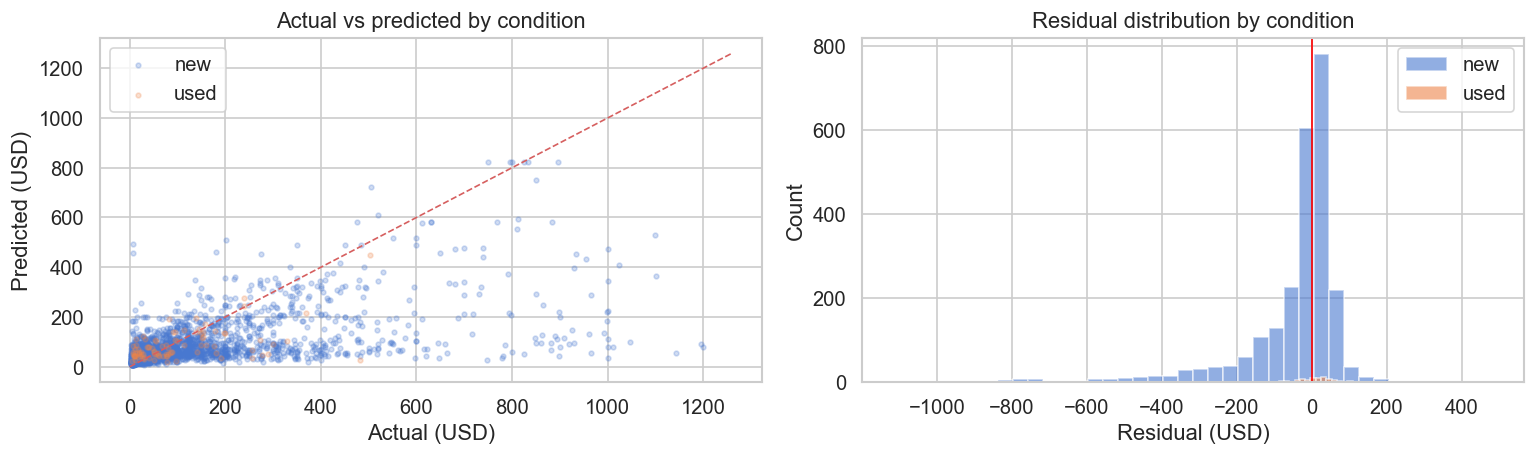

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels_map = {0: 'new', 1: 'used'}

for val, label in labels_map.items():
    mask = is_used_col == val
    if not mask.any():
        continue
    # actual vs predicted per condition
    axes[0].scatter(y_true_usd[mask], y_pred_usd[mask],
                    alpha=0.25, s=8, label=label)
    # residual distribution per condition
    axes[1].hist(y_pred_usd[mask] - y_true_usd[mask],
                 bins=40, alpha=0.6, label=label)

lim = max(y_true_usd.max(), y_pred_usd.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1)
axes[0].set_xlabel('Actual (USD)')
axes[0].set_ylabel('Predicted (USD)')
axes[0].set_title('Actual vs predicted by condition')
axes[0].legend()

axes[1].axvline(0, color='red', linewidth=1)
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution by condition')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. Error Bucket Analysis

What fraction of predictions are within ±10%, ±20%, ±50% of the true price?  
This is the most actionable metric for the pricing agent — the seller cares whether the suggested price is in the right ballpark, not the exact RMSE.

Fraction of predictions within X% of true price:
  Within ± 5%:  4.0%
  Within ±10%:  8.4%
  Within ±20%:  17.5%
  Within ±30%:  26.5%
  Within ±50%:  43.8%


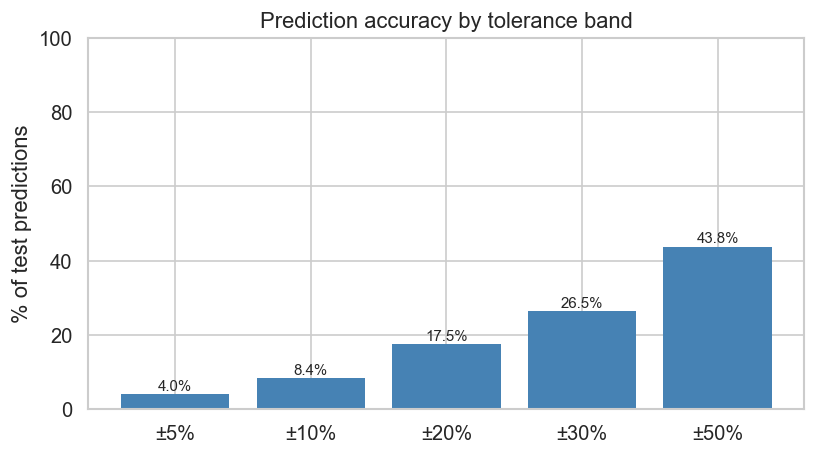

In [10]:
pct_error = np.abs(y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0) * 100

buckets = [5, 10, 20, 30, 50]
print('Fraction of predictions within X% of true price:')
for thr in buckets:
    frac = (pct_error <= thr).mean() * 100
    print(f'  Within ±{thr:2d}%:  {frac:.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
fracs = [(pct_error <= t).mean() * 100 for t in buckets]
ax.bar([f'±{t}%' for t in buckets], fracs, color='steelblue', edgecolor='none')
ax.set_ylabel('% of test predictions')
ax.set_title('Prediction accuracy by tolerance band')
ax.set_ylim(0, 100)
for i, v in enumerate(fracs):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary

### Limitations to keep in mind

- Dataset is **electronics-heavy** (smartphones, headphones). Performance on other categories (clothing, furniture, collectibles) will be degraded until more diverse training data is collected.
- `is_used` flag covers only ~4% of listings in this dataset, so the model has limited exposure to secondhand pricing patterns.
- Features like `seller_rating_pct` and `internal_memory_gb` are sparse; the `-1` sentinel means the model must infer price without them for most real inference calls.

### Next step

The model is ready for integration. `packages/agents/pricing/agent.py` loads `pricing_model.pkl` and blends the XGBoost prediction with the eBay comparable median to produce `recommended_price`.